# Trillingslab v3 — eigen experimenten

Alle parameters zijn synthetische scenario-invoer. Het model berekent geen werkelijke isolatorbreuk.

Dit notebook gebruikt `gvb_simulatie.py` uit dezelfde map, met een onafhankelijke SciPy/DOP853-oplossing. Draai de cellen op volgorde. De browser gebruikt RK4; `pytest` vergelijkt de uitkomsten.

Benodigde pakketten: numpy, scipy, matplotlib. Openbare referenties en modelgrenzen staan in `docs/MODEL.md`.

In [1]:
from dataclasses import replace
from gvb_simulatie import Parameters, simulate, observation_end, parameter_study, plot_simulation
import matplotlib.pyplot as plt
from IPython.display import display

## 1. Invoer bepalen

Kies `single`, `repeat` of `periodic`. d is in mm; de snelheid in km/u; `intervalMs` is de start-tot-starttijd. Bij periodieke invoer bepalen `frequency` en `cycles` het tijdprofiel. Positie en snelheid worden **niet opnieuw ingesteld tussen pulsen**.

In [2]:
p = Parameters(profile="repeat", pulseCount=5, intervalMs=45, depth=1,
               mass=10, stiffness=200000, damping=0.05, length=0.15, speed=36)
resultaat = simulate(p)
resultaat.summary()

{'parameters': {'mass': 10,
  'stiffness': 200000,
  'damping': 0.05,
  'depth': 1,
  'length': 0.15,
  'speed': 36,
  'profile': 'repeat',
  'pulseCount': 5,
  'intervalMs': 45,
  'frequency': 22.0,
  'cycles': 12},
 'fn': 22.507907903927652,
 'rmax': 538.8987905035128,
 'zmax': 0.002680903200901861,
 'xmax': 0.002680903200901861,
 'peakTime': 0.24611056268509376,
 'end': 0.6950000000000001,
 'samples': 4800}

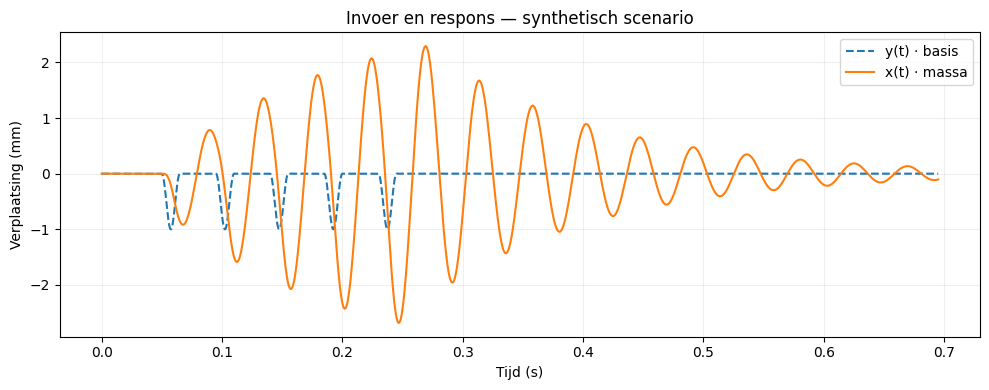

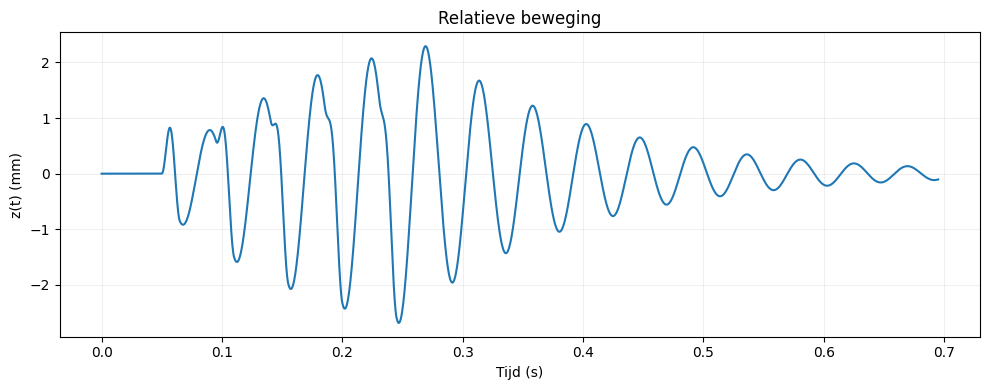

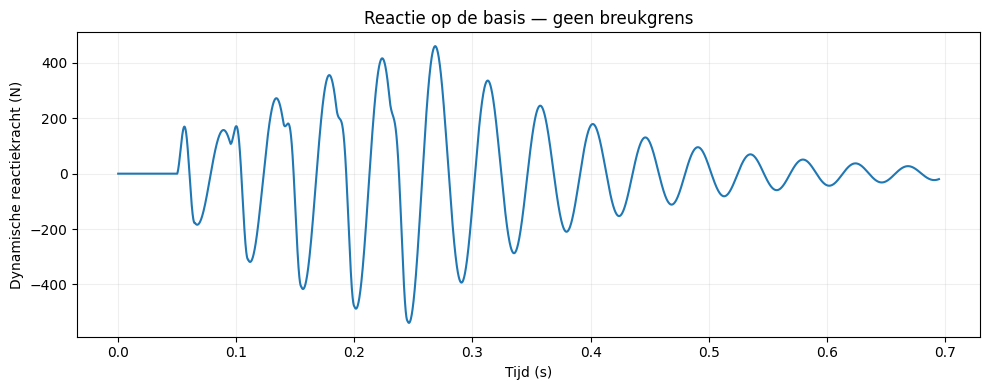

In [3]:
figuren = plot_simulation(resultaat)
for figuur in figuren:
    display(figuur)
plt.close("all")

## 2. Eén puls tegenover vijf pulsen

Alle overige parameters en het eindtijdstip zijn gelijk. De vergelijking betreft dynamische reactie, niet vermoeiingsschade.

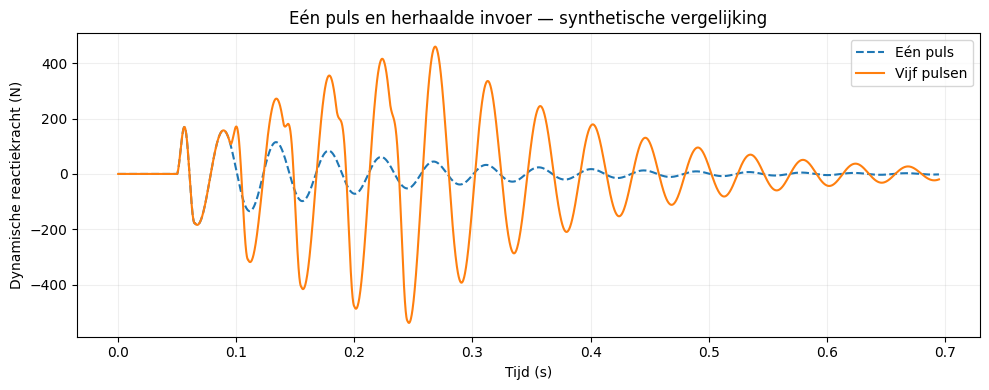

In [4]:
enkel = replace(p, profile="single")
eind = observation_end([p, enkel])
a = simulate(enkel, end_s=eind)
b = simulate(p, end_s=eind)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(a.t, a.reaction, "--", label="Eén puls")
ax.plot(b.t, b.reaction, label="Vijf pulsen")
ax.set(xlabel="Tijd (s)", ylabel="Dynamische reactiekracht (N)",
       title="Eén puls en herhaalde invoer — synthetische vergelijking")
ax.legend(); ax.grid(alpha=0.2); fig.tight_layout()
plt.show()

## 3. Pulsafstand onderzoeken

In deze reeks verandert alleen de start-tot-starttijd. Een lijn verbindt de berekende punten voor leesbaarheid; tussenliggende waarden zijn niet berekend. Het hoogste rasterpunt is niet automatisch het maximum over alle mogelijke pulsafstanden.

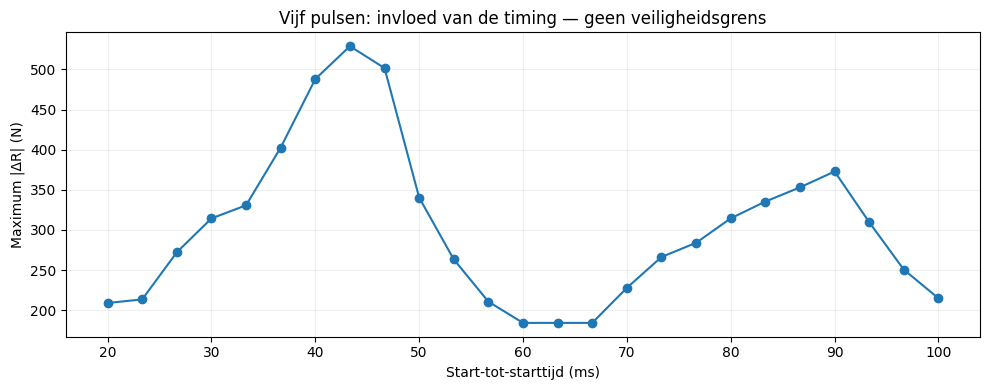

{'value': 43.333333333333336,
 'parameters': {'mass': 10,
  'stiffness': 200000,
  'damping': 0.05,
  'depth': 1,
  'length': 0.15,
  'speed': 36,
  'profile': 'repeat',
  'pulseCount': 5,
  'intervalMs': 43.333333333333336,
  'frequency': 22.0,
  'cycles': 12},
 'fn': 22.507907903927652,
 'rmax': 528.8388484888438,
 'zmax': 0.0026310105396756315,
 'xmax': 0.0026310105396756315,
 'peakTime': 0.24188655508150095,
 'end': 0.915,
 'samples': 5789}

In [5]:
reeks = parameter_study(p, "intervalMs", 20, 100, 25)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([r["value"] for r in reeks], [r["rmax"] for r in reeks], "o-")
ax.set(xlabel="Start-tot-starttijd (ms)", ylabel="Maximum |ΔR| (N)",
       title="Vijf pulsen: invloed van de timing — geen veiligheidsgrens")
ax.grid(alpha=0.2); fig.tight_layout(); plt.show()
max(reeks, key=lambda r: r["rmax"])

## 4. Vervolgproef

Herhaal de reeks over een smaller interval rond een interessante piek. Vergelijk daarna de dempingsverhouding bij dezelfde invoer. Voor periodieke invoer: gebruik `replace(p, profile="periodic", frequency=22, cycles=12)` en varieer `frequency`. Een eindig aantal perioden is geen stationaire frequentierespons.

Rapporteer vraag → modelkeuze → vaste parameters → resultaat → controles → beperking.